In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df_ankle = pd.read_csv('../data/processed/ankle_injuries.csv')
df_knee = pd.read_csv('../data/processed/knee_injuries.csv')
df_ankle.head()
df_knee.head()

,PLAYER_ID,PLAYER_NAME,SEASON,SEASON_NUM,AGE,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,GP,MIN,USG_PCT,...,PASSES_MADE,PASSES_RECEIVED,SECONDARY_AST,POTENTIAL_AST,AST_ADJ,AST_TO_PASS_PCT,AST_TO_PASS_PCT_ADJ,OREB_CHANCE_PCT,DREB_CHANCE_PCT,REB_CHANCE_PCT_ADJ
0,101107,Marvin Williams,18-19,18.5,33.0,81.0,237.0,75,28.4,0.147,...,26.9,23.8,0.1,2.0,1.3,0.046,0.049,0.404,0.590,0.609
1,204020,Tyler Johnson,14-15,14.5,23.0,75.0,190.0,32,18.8,0.161,...,22.7,22.8,0.2,3.8,1.8,0.058,0.077,0.232,0.536,0.471
2,201196,Ramon Sessions,15-16,15.5,30.0,75.0,190.0,82,20.3,0.214,...,30.6,36.3,0.4,6.0,3.7,0.095,0.121,0.214,0.659,0.550
3,203496,Robert Covington,14-15,14.5,24.0,81.0,215.0,70,27.9,0.213,...,29.8,30.8,0.2,3.3,1.9,0.050,0.064,0.301,0.532,0.497
4,1630595,Cade Cunningham,22-23,22.5,21.0,79.0,220.0,12,33.3,0.287,...,50.3,65.8,0.4,12.6,8.3,0.119,0.164,0.375,0.639,0.607


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_43888\2819528696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Injury_Group', y='DAYS_MISSED', data=df_combined, palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_43888\2819528696.py:22: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(axis='y', linestyle='-', alpha=0.5, visible=False)


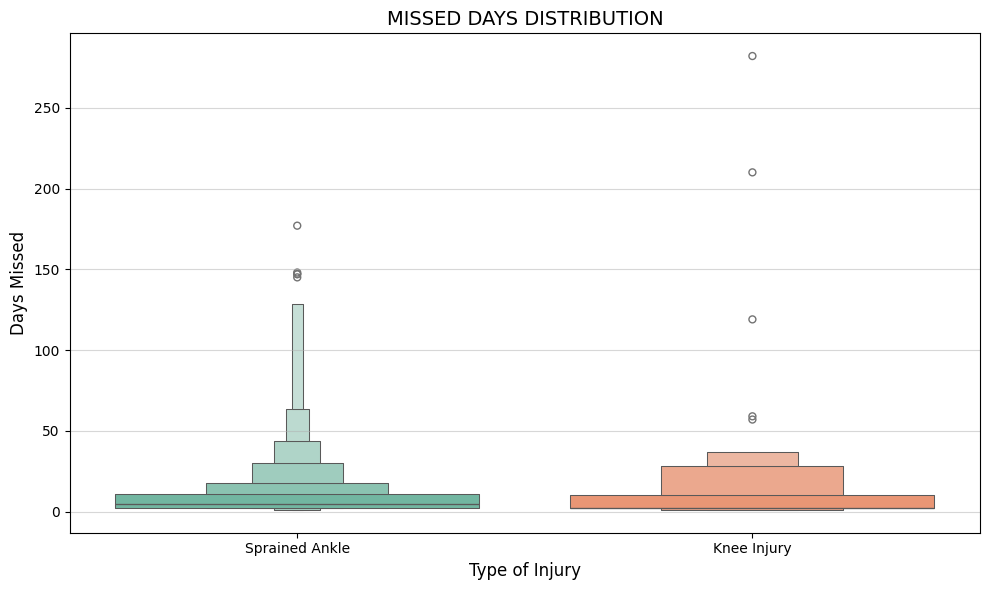

In [ ]:
# 1. Load data (nhu ban da lam)
df_ankle = pd.read_csv('../data/processed/ankle_injuries.csv')
df_knee = pd.read_csv('../data/processed/knee_injuries.csv')

# 2. Gop hai DataFrame lai de so sanh
# Chung ta se them mot cot 'Injury_Type' de phan biet khi ve
df_ankle['Injury_Group'] = 'Sprained Ankle'
df_knee['Injury_Group'] = 'Knee Injury'

df_combined = pd.concat([df_ankle, df_knee], ignore_index=True)

# 3. Ve Boxen Plot
plt.figure(figsize=(10, 6))

# Su dung sns.boxenplot de tri du lieu co duoi dai (heavy-tailed)
sns.boxenplot(x='Injury_Group', y='DAYS_MISSED', data=df_combined, palette='Set2')

# Tuy chinh bieu do cho chuyen nghiep
plt.title('MISSED DAYS DISTRIBUTION', fontsize=14)
plt.xlabel('Type of Injury', fontsize=12)
plt.ylabel('Days Missed', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.5, visible=False)

# (Tuy chon) Neu du lieu van con qua lech, ban co the uncomment dong duoi de dung thang Log
# plt.yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ankle = pd.read_csv('../data/processed/ankle_injuries.csv')
knee  = pd.read_csv('../data/processed/knee_injuries.csv')

# Danh sach feature da bo sung day du nhom The chat & Suc khoe nen
features = [
    'AGE', 'PLAYER_HEIGHT_INCHES', 'PLAYER_WEIGHT', 'GP', 'MIN',
    'USG_PCT', 'PACE', 'POSS',
    'DIST_MILES', 'DIST_MILES_OFF', 'DIST_MILES_DEF',
    'AVG_SPEED', 'AVG_SPEED_OFF', 'AVG_SPEED_DEF',
    'DRIVES', 'DRIVE_FGA', 'DRIVE_TOV',
    'TOUCHES', 'PAINT_TOUCHES', 'POST_TOUCHES',
    'ELBOW_TOUCHES', 'FRONT_CT_TOUCHES',
    'AVG_DRIB_PER_TOUCH', 'AVG_SEC_PER_TOUCH', 'TIME_OF_POSS', 'PULL_UP_FGA'
 ]

def prepare_aggregated_df(df, features, target='DAYS_MISSED'):
    df = df.copy()
    if target in df.columns:
        df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0)

    for f in features:
        if f in df.columns:
            df[f] = pd.to_numeric(
                df[f].replace({' None': np.nan, 'None': np.nan}),
                errors='coerce'
            )

    agg_logic = {f: 'mean' for f in features if f in df.columns}
    agg_logic[target] = 'sum'
    return df.groupby(['PLAYER_NAME', 'SEASON']).agg(agg_logic).reset_index()

def spearman_corr(df, features, target='DAYS_MISSED'):
    results = {}
    for f in features:
        if f in df.columns and target in df.columns:
            valid = df[[f, target]].dropna()
            if len(valid) >= 2:
                rho, pval = stats.spearmanr(valid[f], valid[target])
                results[f] = (rho, pval)
    return results

ankle_agg = prepare_aggregated_df(ankle, features)
knee_agg  = prepare_aggregated_df(knee, features)

ankle_corr = spearman_corr(ankle_agg, features)
knee_corr  = spearman_corr(knee_agg, features)

available_features = [f for f in features if f in ankle_corr or f in knee_corr]
sorted_features = sorted(available_features, key=lambda f: ankle_corr.get(f, (0, 1))[0])
ankle_rhos  = [ankle_corr.get(f, (np.nan, 1))[0] for f in sorted_features]
knee_rhos   = [knee_corr.get(f, (np.nan, 1))[0] for f in sorted_features]
ankle_pvals = [ankle_corr.get(f, (np.nan, 1))[1] for f in sorted_features]
knee_pvals  = [knee_corr.get(f, (np.nan, 1))[1] for f in sorted_features]

# Gan nhom feature day du theo yeu cau
feature_groups = {
    'AGE': 'Physical & Baseline Health',
    'PLAYER_HEIGHT_INCHES': 'Physical & Baseline Health',
    'PLAYER_WEIGHT': 'Physical & Baseline Health',
    'GP': 'Physical & Baseline Health',
    'MIN': 'Physical & Baseline Health',

    'USG_PCT': 'Tracking Workload',
    'PACE': 'Tracking Workload',
    'POSS': 'Tracking Workload',

    'DIST_MILES': 'Tracking Movement',
    'DIST_MILES_OFF': 'Tracking Movement',
    'DIST_MILES_DEF': 'Tracking Movement',
    'AVG_SPEED': 'Tracking Movement',
    'AVG_SPEED_OFF': 'Tracking Movement',
    'AVG_SPEED_DEF': 'Tracking Movement',

    'DRIVES': 'Tracking Contact & Burst',
    'DRIVE_FGA': 'Tracking Contact & Burst',
    'DRIVE_TOV': 'Tracking Contact & Burst',
    'TOUCHES': 'Tracking Contact & Burst',
    'PAINT_TOUCHES': 'Tracking Contact & Burst',
    'POST_TOUCHES': 'Tracking Contact & Burst',
    'ELBOW_TOUCHES': 'Tracking Contact & Burst',
    'FRONT_CT_TOUCHES': 'Tracking Contact & Burst',

    'AVG_DRIB_PER_TOUCH': 'Tracking Dribble & Control',
    'AVG_SEC_PER_TOUCH': 'Tracking Dribble & Control',
    'TIME_OF_POSS': 'Tracking Dribble & Control',
    'PULL_UP_FGA': 'Tracking Dribble & Control',
}

# Luu them bang gia tri Spearman + p-value
spearman_value_table = pd.DataFrame({
    'Feature': sorted_features,
    'Feature_Group': [feature_groups.get(f, 'Other') for f in sorted_features],
    'Ankle_Rho': ankle_rhos,
    'Ankle_pval': ankle_pvals,
    'Knee_Rho': knee_rhos,
    'Knee_pval': knee_pvals,
})
spearman_value_table.to_csv('../data/processed/spearman_correlation_values_light.csv', index=False)
print('Saved: ../data/processed/spearman_correlation_values_light.csv')
display(spearman_value_table.head(10))

# Giu style chart trang hien tai
BG_COLOR = '#ffffff'
AX_COLOR = '#f8f9fa'
TEXT_COLOR = '#2d3436'
GRID_COLOR = '#dfe6e9'
LINE_COLOR = '#636e72'

ANKLE_COLOR = '#d35400'
KNEE_COLOR  = '#2980b9'
STAR_COLOR  = '#c0392b'

# Mau nhom diu hon de hop nen trang
group_colors = {
    'Physical & Baseline Health': '#6B7280',
    'Tracking Workload': '#2F6F6F',
    'Tracking Movement': '#3E5F8A',
    'Tracking Contact & Burst': '#8A5A44',
    'Tracking Dribble & Control': '#7A6A3A',
}

fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AX_COLOR)

n = len(sorted_features)
y = np.arange(n)
bar_height, gap = 0.35, 0.04

ax.barh(y - bar_height/2 - gap/2, ankle_rhos, bar_height, color=ANKLE_COLOR, alpha=0.85, zorder=3)
ax.barh(y + bar_height/2 + gap/2, knee_rhos,  bar_height, color=KNEE_COLOR,  alpha=0.85, zorder=3)

for i, (rho, pv) in enumerate(zip(ankle_rhos, ankle_pvals)):
    if pd.notna(rho) and pd.notna(pv) and pv < 0.05:
        ax.text(rho + (0.005 if rho >= 0 else -0.005), i - bar_height/2 - gap/2,
                '*', ha='left' if rho >= 0 else 'right', va='center',
                fontsize=13, color=STAR_COLOR, fontweight='bold', zorder=5)

for i, (rho, pv) in enumerate(zip(knee_rhos, knee_pvals)):
    if pd.notna(rho) and pd.notna(pv) and pv < 0.05:
        ax.text(rho + (0.005 if rho >= 0 else -0.005), i + bar_height/2 + gap/2,
                '*', ha='left' if rho >= 0 else 'right', va='center',
                fontsize=13, color=STAR_COLOR, fontweight='bold', zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_features, fontsize=10.5, fontweight='500')
for tick, f in zip(ax.get_yticklabels(), sorted_features):
    tick.set_color(group_colors.get(feature_groups.get(f, ''), TEXT_COLOR))

ax.axvline(0, color=LINE_COLOR, linewidth=1.5, zorder=2)
x_min = np.nanmin(ankle_rhos + knee_rhos)
x_max = np.nanmax(ankle_rhos + knee_rhos)
ax.set_xlim(min(-0.35, x_min - 0.05), max(0.45, x_max + 0.05))
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.tick_params(axis='x', colors=TEXT_COLOR, labelsize=10)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8, linestyle='-', zorder=1)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Spearman Correlation: Features vs Days Missed (rho)',
             color=TEXT_COLOR, fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Spearman Correlation Coefficient (rho)', color=TEXT_COLOR, fontsize=12, labelpad=12)
ax.set_ylabel('Workload Features', color=TEXT_COLOR, fontsize=12, labelpad=12)

l1 = ax.legend(handles=[
    mpatches.Patch(facecolor=ANKLE_COLOR, alpha=0.85, label='Ankle Injuries'),
    mpatches.Patch(facecolor=KNEE_COLOR,  alpha=0.85, label='Knee Injuries'),
    plt.Line2D([0], [0], color='white', marker='*', markerfacecolor=STAR_COLOR,
               markersize=10, label='p < 0.05 significance', linestyle='None'),
], title='Injury Type', title_fontsize=11, loc='lower right',
   facecolor='white', edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR, fontsize=10)
ax.add_artist(l1)

ax.legend(handles=[mpatches.Patch(facecolor=c, label=g, alpha=0.8)
                   for g, c in group_colors.items()],
          title='Feature Group', title_fontsize=11, loc='upper right',
          facecolor='white', edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR, fontsize=10)

plt.tight_layout(pad=2.0)

Saved: spearman_correlation_values_light.csv


,Feature,Feature_Group,Ankle_Rho,Ankle_pval,Knee_Rho,Knee_pval
0,AVG_SPEED_DEF,Tracking Movement,-0.072353,4.434050e-07,-0.056738,0.000163
1,AGE,Physical & Baseline Health,-0.055370,1.124532e-04,0.019969,0.184829
2,AVG_SPEED,Tracking Movement,-0.045419,1.541319e-03,-0.037258,0.013347
3,AVG_SPEED_OFF,Tracking Movement,-0.011494,4.230860e-01,-0.026234,0.081483
4,PLAYER_WEIGHT,Physical & Baseline Health,0.011018,4.425188e-01,-0.001063,0.943744
5,PLAYER_HEIGHT_INCHES,Physical & Baseline Health,0.024912,8.246813e-02,-0.000300,0.984096
6,AVG_DRIB_PER_TOUCH,Tracking Dribble & Control,0.028103,5.010671e-02,0.031235,0.038043
7,AVG_SEC_PER_TOUCH,Tracking Dribble & Control,0.030547,3.321096e-02,0.031900,0.034128
8,PACE,Tracking Workload,0.037034,9.822066e-03,0.017958,0.233083
9,POST_TOUCHES,Tracking Contact & Burst,0.080864,1.650620e-08,0.022349,0.137791


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_43888\944430188.py:190: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [5]:
# 2. Tiền xử lý dữ liệu
# Chuyển DAYS_MISSED sang số, điền 0 cho các trường hợp thiếu
df_knee['DAYS_MISSED'] = pd.to_numeric(df_knee['DAYS_MISSED'], errors='coerce').fillna(0)

# Chuyển TOUCHES sang số, xử lý chuỗi ' None' đặc thù trong dataset
df_knee['TOUCHES'] = pd.to_numeric(
    df_knee['TOUCHES'].replace({' None': np.nan, 'None': np.nan}), 
    errors='coerce'
)

# 3. Lọc mẫu cho kiểm định (Chỉ lấy các ca thực sự chấn thương để đo mức độ nặng)
# n = 86 như trong bảng thống kê mô tả của bạn
knee_injured = df_knee[
    (df_knee['INJURED_TYPE'] == 'Knee_injury') & 
    (df_knee['DAYS_MISSED'] > 0)
].dropna(subset=['TOUCHES'])

# 4. Chia nhóm dựa trên Trung vị (Median) của TOUCHES
median_touches = knee_injured['TOUCHES'].median()

# Nhóm A: Chạm bóng nhiều (High Workload)
group_high = knee_injured[knee_injured['TOUCHES'] > median_touches]['DAYS_MISSED']
# Nhóm B: Chạm bóng ít (Low Workload)
group_low = knee_injured[knee_injured['TOUCHES'] <= median_touches]['DAYS_MISSED']

# 5. Thực hiện Independent T-test
# alternative='greater' để kiểm chứng giả thuyết: Chạm bóng nhiều -> Nghỉ nhiều hơn
t_stat, p_val = stats.ttest_ind(group_high, group_low, alternative='greater')

# 6. Xuất kết quả
print(f"--- KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT (KNEE INJURY) ---")
print(f"Biến kiểm định: TOUCHES (Spearman Rho cao nhất)")
print(f"Trung vị Touches: {median_touches:.2f}")
print("-" * 45)
print(f"Số mẫu Nhóm Cao: {len(group_high)} | Nghỉ TB: {group_high.mean():.2f} ngày")
print(f"Số mẫu Nhóm Thấp: {len(group_low)} | Nghỉ TB: {group_low.mean():.2f} ngày")
print("-" * 45)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Biện luận logic
if p_val < 0.05:
    print("\n=> KẾT LUẬN: Bác bỏ H0. Số lần chạm bóng có ảnh hưởng đến mức độ nặng của chấn thương gối.")
else:
    print("\n=> KẾT LUẬN: Không đủ bằng chứng để bác bỏ H0 (P > 0.05).")

--- KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT (KNEE INJURY) ---
Biến kiểm định: TOUCHES (Spearman Rho cao nhất)
Trung vị Touches: 47.20
---------------------------------------------
Số mẫu Nhóm Cao: 38 | Nghỉ TB: 11.76 ngày
Số mẫu Nhóm Thấp: 48 | Nghỉ TB: 18.06 ngày
---------------------------------------------
T-statistic: -0.7216
P-value: 0.7637

=> KẾT LUẬN: Không đủ bằng chứng để bác bỏ H0 (P > 0.05).


In [7]:
# 2. Tiền xử lý dữ liệu
# Chuyển DAYS_MISSED sang số, điền 0 cho các trường hợp thiếu
df_ankle['DAYS_MISSED'] = pd.to_numeric(df_ankle['DAYS_MISSED'], errors='coerce').fillna(0)

# Chuyển DIST_MILES sang số, xử lý chuỗi ' None' đặc thù trong dataset
df_ankle['DIST_MILES'] = pd.to_numeric(
    df_ankle['DIST_MILES'].replace({' None': np.nan, 'None': np.nan}), 
    errors='coerce'
)

# 3. Lọc mẫu cho kiểm định (Chỉ lấy các ca thực sự chấn thương để đo mức độ nặng)
# n = 86 như trong bảng thống kê mô tả của bạn
ankle_injured = df_ankle[
    (df_ankle['INJURED_TYPE'] == 'Sprained_ankle') & 
    (df_ankle['DAYS_MISSED'] > 0)
].dropna(subset=['DIST_MILES'])

# 4. Chia nhóm dựa trên Trung vị (Median) của DIST_MILES
median_dist_miles = ankle_injured['DIST_MILES'].median()

# Nhóm A: Chạm bóng nhiều (High Workload)
group_high = ankle_injured[ankle_injured['DIST_MILES'] > median_dist_miles]['DAYS_MISSED']
# Nhóm B: Chạm bóng ít (Low Workload)
group_low = ankle_injured[ankle_injured['DIST_MILES'] <= median_dist_miles]['DAYS_MISSED']

# 5. Thực hiện Independent T-test
# alternative='greater' để kiểm chứng giả thuyết: Chạm bóng nhiều -> Nghỉ nhiều hơn
t_stat, p_val = stats.ttest_ind(group_high, group_low, alternative='greater')

# 6. Xuất kết quả
print(f"--- KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT (ANKLE INJURY) ---")
print(f"Biến kiểm định: DIST_MILES (Spearman Rho cao nhất)")
print(f"Trung vị DIST_MILES: {median_dist_miles:.2f}")
print("-" * 45)
print(f"Số mẫu Nhóm Cao: {len(group_high)} | Nghỉ TB: {group_high.mean():.2f} ngày")
print(f"Số mẫu Nhóm Thấp: {len(group_low)} | Nghỉ TB: {group_low.mean():.2f} ngày")
print("-" * 45)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Biện luận logic
if p_val < 0.05:
    print("\n=> KẾT LUẬN: Bác bỏ H0. Số lần chạm bóng có ảnh hưởng đến mức độ nặng của chấn thương cổ chân.")
else:
    print("\n=> KẾT LUẬN: Không đủ bằng chứng để bác bỏ H0 (P > 0.05).")

--- KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT (ANKLE INJURY) ---
Biến kiểm định: DIST_MILES (Spearman Rho cao nhất)
Trung vị DIST_MILES: 1.85
---------------------------------------------
Số mẫu Nhóm Cao: 293 | Nghỉ TB: 9.13 ngày
Số mẫu Nhóm Thấp: 295 | Nghỉ TB: 11.36 ngày
---------------------------------------------
T-statistic: -1.5266
P-value: 0.9363

=> KẾT LUẬN: Không đủ bằng chứng để bác bỏ H0 (P > 0.05).
